In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [19]:
df = pd.read_csv('clean_jobvision.csv')

In [21]:

level_map = {
    "مقدماتی": 1,
    "متوسط": 2,
    "حرفه‌ای": 3,
    "حرفه اي": 3,
    "حرفه ای": 3
}

In [ ]:
def count_skills(x):
   
    if pd.isna(x) or x == "نامشخص":
        return 0

    skills = [s.strip() for s in str(x).split(',')]
  
    skills = [s for s in skills if s not in ["", " "]]
    
    return len(skills)

df['skills_count'] = df['all_skills'].apply(count_skills)


In [22]:
df['skills_count'].unique()

array([ 0,  9,  6,  1,  7,  4,  2, 10, 18,  3,  5,  8, 12, 15, 11, 17, 19,
       13, 29, 24, 16, 14, 39, 26, 34, 54, 62, 20, 35, 28])

In [17]:
df['all_skills'].head(10)


0                                               نامشخص
1    ایلاستریتور,ایلوستریتور, ایندیزاین,این دیزاین,...
2    اچ تی ام ال,سی اس اس, جاوا اسکریپت, , ری اکت, ...
3                                               نامشخص
4                                               ری اکت
5     اکسس, اکسل, ورد, ویزیو, فتوشاپ,فوتوشاپ, پی اچ پی
6                                               نامشخص
7                                               نامشخص
8                                               نامشخص
9               وردپرس, اچ تی ام ال,سی اس اس, پی اچ پی
Name: all_skills, dtype: object

آیا حقوق و مهارت با هم رابطه معناداری دارند؟.............................................................................................................................................................................................

Spearman correlation: 0.024594483854558237
p-value: 6.200652433468953e-50


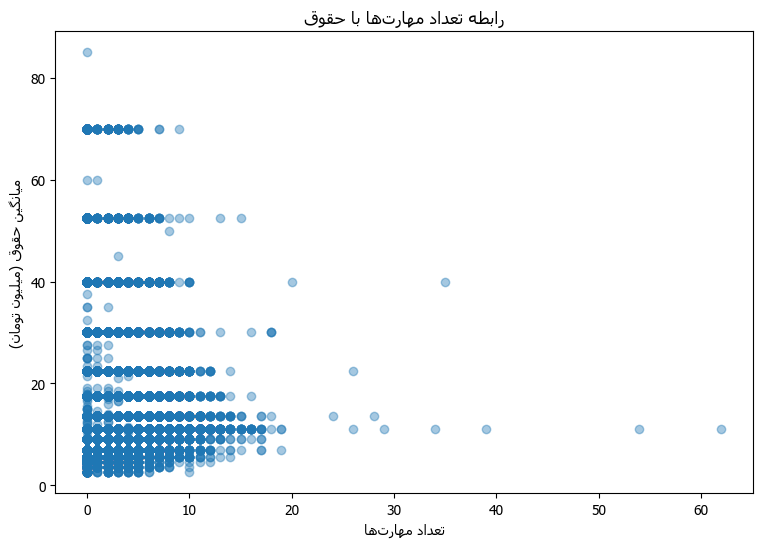

In [23]:


plt.rcParams['font.family'] = 'Tahoma'

title = get_display(arabic_reshaper.reshape("رابطه تعداد مهارت‌ها با حقوق"))


df['salary_mean'] = (df['Jobpost_MinSalary'] + df['Jobpost_MaxSalary']) / 2

corr, p = spearmanr(df['skills_count'], df['salary_mean'], nan_policy='omit')
print("Spearman correlation:", corr)
print("p-value:", p)

plt.figure(figsize=(9,6))
plt.scatter(df['skills_count'], df['salary_mean'], alpha=0.4)

plt.xlabel(get_display(arabic_reshaper.reshape("تعداد مهارت‌ها")))
plt.ylabel(get_display(arabic_reshaper.reshape("میانگین حقوق (میلیون تومان)")))
plt.title(title)

plt.show()


رابطه بین تعداد مهارت حتی با تاثیر سطح مهارت و حقوق معنا دار نبوده است 

حال بررسی کنیم ببینیم اگر سطح مهارت را دخیل کنیم رابطه معناداری یافت می شود؟............................................................................................................

In [25]:
def skill_power(x, levels):
   
    if pd.isna(x) or pd.isna(levels):
        return 0
    if x == "نامشخص" or levels == "نامشخص":
        return 0

    skills = [s.strip() for s in str(x).split(',') if s.strip() not in ["", " "]]
    lvls   = [l.strip() for l in str(levels).split(',') if l.strip() not in ["", " "]]

    pairs = zip(skills, lvls)

    total = 0
    for skill, lvl in pairs:
        score = level_map.get(lvl, 0) 
        total += score

    return total


df['skill_power'] = df.apply(lambda row: skill_power(row['all_skills'], row['all_skills_levels']), axis=1)



In [26]:
corr, p = spearmanr(df['skill_power'], df['salary_mean'], nan_policy='omit')
print("Skill Power correlation:", corr)
print("p-value:", p)


Skill Power correlation: 0.010255453375324231
p-value: 5.842497283443746e-10


رابطه بین تعداد مهارت حتی با تاثیر سطح مهارت و حقوق معنا دار نبوده است 

آیا حقوق و سابقه کار با هم رابطه معناداری دارند؟.............................................................................................................................................................................................

In [27]:
df['salary'] = (df['Jobpost_MinSalary'] + df['Jobpost_MaxSalary']) / 2


In [28]:


corr, p = spearmanr(df['Jobpost_RequiredExperienceYears'], df['salary'])

print("Spearman correlation:", corr)
print("p-value:", p)


Spearman correlation: 0.19207264259992088
p-value: 0.0


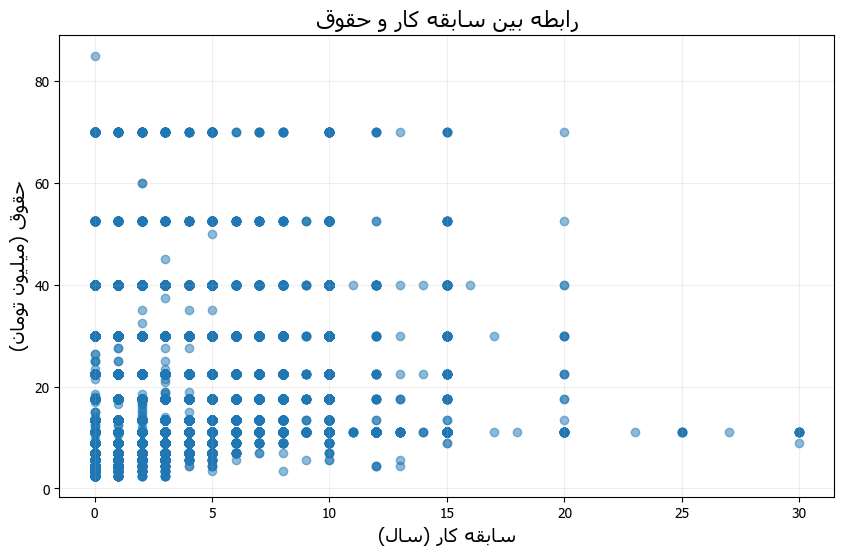

In [29]:


plt.rcParams['font.family'] = 'Tahoma'

xlabel = get_display(arabic_reshaper.reshape("سابقه کار (سال)"))
ylabel = get_display(arabic_reshaper.reshape("حقوق (میلیون تومان)"))
title  = get_display(arabic_reshaper.reshape("رابطه بین سابقه کار و حقوق"))

plt.figure(figsize=(10, 6))
plt.scatter(df['Jobpost_RequiredExperienceYears'], df['salary'], alpha=0.5)

plt.xlabel(xlabel, fontsize=14)
plt.ylabel(ylabel, fontsize=14)
plt.title(title, fontsize=16)

plt.grid(alpha=0.2)
plt.show()


Correlation = 0.192
یعنی رابطهٔ سابقه کار و حقوق مثبت ولی ضعیف است.

مقدار 0.19 نشان می‌دهد که هرچه سابقه بیشتر باشد، حقوق معمولاً کمی بالاتر است، ولی شدت اثر زیاد نیست.

p-value = 0.0
یعنی این رابطه از نظر آماری کاملاً معنادار است و نمی‌توان گفت تصادفی است.

پس چه عواملی در تعیین حقوق دخیل هستند؟ .............................................................................................................................................................................................

In [31]:

num_features = ['Jobpost_RequiredExperienceYears', 'skills_count', 'skill_power']

cat_features = ['Jobpost_Group', 'degree']  
X = df[num_features + cat_features]
y = df['salary']


In [35]:

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough' 
)


model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])


model.fit(X, y)


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:

feature_names = model.named_steps['preprocess'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values(by='coefficient', key=abs, ascending=False)

importance


,feature,coefficient
16,cat__degree_دکترا,1.398044
4,cat__Jobpost_Group_خدمات,-0.897929
9,cat__Jobpost_Group_فروش و بازاریابی,0.880622
10,cat__Jobpost_Group_فناوری و نرم افزار,0.769106
6,cat__Jobpost_Group_سایر مشاغل,-0.752693
19,cat__degree_کارشناسی,-0.613947
18,cat__degree_کاردانی,-0.596665
5,cat__Jobpost_Group_روابط عمومی,-0.501297
11,cat__Jobpost_Group_لجستیک و انبار,-0.484208
21,remainder__Jobpost_RequiredExperienceYears,0.470422


تحصیلات بیشترین اثر مثبت را دارد

cat__degree_دکترا : ضریب +1.398 : داشتن دکترا باعث افزایش حقوق می‌شود

کارشناسی و کاردانی ضرایب منفی دارند → نسبت به پایه دکترا حقوق کمتر است

گروه شغلی (Jobpost_Group) هم مهم است

برخی گروه‌ها مثل فروش و بازاریابی و فناوری و نرم افزار ضریب مثبت دارند : حقوق بالاتر

گروه‌هایی مثل خدمات و سایر مشاغل ضریب منفی دارند : حقوق کمتر

سابقه کار اثر متوسط دارد

Jobpost_RequiredExperienceYears : ضریب +0.47 : 

افزایش سابقه کار حقوق را کمی بالا می‌برد

تعداد مهارت‌ها و سطحشان تقریباً اثر ندارد

skill_power : ضریب -0.021

skills_count : ضریب -0.014
یعنی همان‌طور که قبلاً مشاهده کردیم، مهارت‌ها عملاً پیش‌بینی‌کنندهٔ اصلی حقوق نیستند